# Zadanie 1

## Importy

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import fbeta_score, make_scorer, confusion_matrix, classification_report, brier_score_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier

## EDA

### Informacje o zbiorze danych


In [38]:
data_dir = Path("") / "data"
df = pd.read_csv(data_dir / "ObesityDataSet_raw_and_data_sinthetic.csv")

print(df.shape)

(2111, 17)


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [40]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [41]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [42]:
cols_to_map = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
for col in cols_to_map:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")

Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
family_history_with_overweight: <StringArray>
['yes', 'no']
Length: 2, dtype: str
FAVC: <StringArray>
['no', 'yes']
Length: 2, dtype: str
CAEC: <StringArray>
['Sometimes', 'Frequently', 'Always', 'no']
Length: 4, dtype: str
SMOKE: <StringArray>
['no', 'yes']
Length: 2, dtype: str
SCC: <StringArray>
['no', 'yes']
Length: 2, dtype: str
CALC: <StringArray>
['no', 'Sometimes', 'Frequently', 'Always']
Length: 4, dtype: str
MTRANS: <StringArray>
['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Length: 5, dtype: str
NObeyesdad: <StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str


### Zamiana danych tekstowych na liczbowe 

In [43]:
binary_map = {'no': 0, 'yes': 1}
gender_map = {'Female': 0, 'Male': 1}
freq_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
trans_map = {'Public_Transportation': 0, 'Walking': 1, 'Automobile': 2, 'Motorbike': 3, 'Bike': 4}
obesity_types = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

In [44]:
df['Gender'] = df['Gender'].map(gender_map)

df['family_history_with_overweight'] = df['family_history_with_overweight'].map(binary_map)
df['FAVC'] = df['FAVC'].map(binary_map)
df['SMOKE'] = df['SMOKE'].map(binary_map)
df['SCC'] = df['SCC'].map(binary_map)

df['CAEC'] = df['CAEC'].map(freq_map)
df['CALC'] = df['CALC'].map(freq_map)

df["MTRANS"] = df["MTRANS"].map(trans_map)

df['NObeyesdad'] = df['NObeyesdad'].apply(lambda x: 1 if x in obesity_types else 0)

### Balans klas targetu

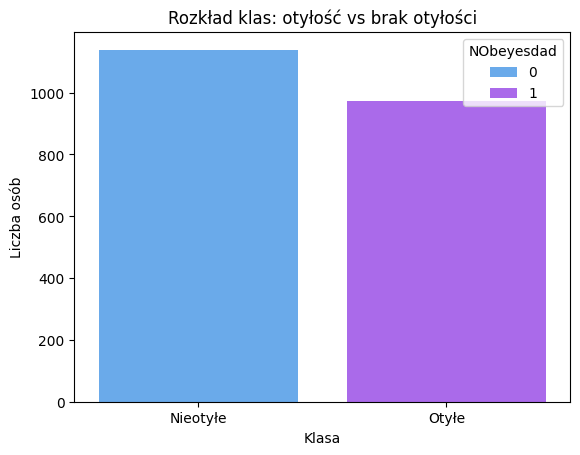

In [45]:
counts = df["NObeyesdad"].value_counts()

sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="cool")
plt.title("Rozkład klas: otyłość vs brak otyłości")
plt.xlabel("Klasa")
plt.ylabel("Liczba osób")
plt.xticks([0, 1], ["Nieotyłe", "Otyłe"])
plt.show()

Widzimy, że klasy są zbalansowane

### Macierz korelacji

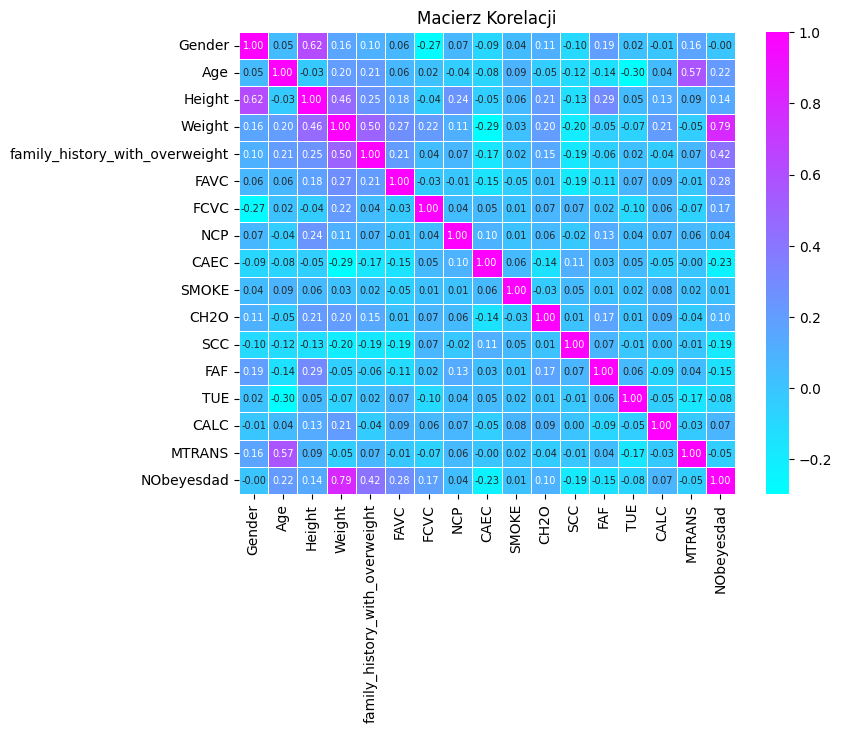

In [46]:
df_corr = df.copy()
df_corr["NObeyesdad"] = df_corr["NObeyesdad"].astype(int)
corr = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="cool", fmt=".2f", linewidths=0.5, annot_kws={"size": 7})
plt.title("Macierz Korelacji")
plt.show()

### Usuwanie atrybutów
usuwamy zarówno wzrost, jak i wagę, bo dzięki tym danym wystarczyłoby liczyć bmi

In [47]:
df = df.drop(columns=['Weight', 'Height'])

### Wizualizacja rozkładu wieku

<Axes: xlabel='Age', ylabel='Count'>

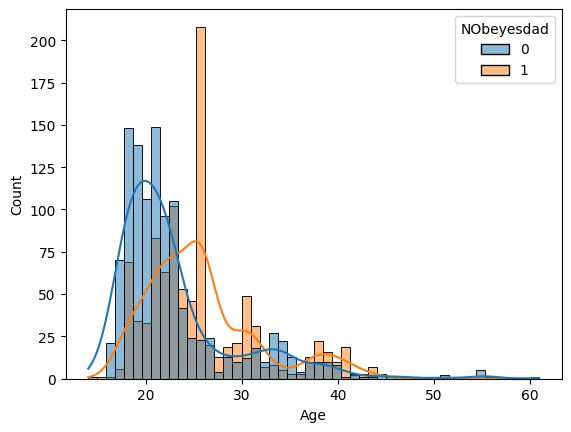

In [48]:
sns.histplot(data=df, x='Age', hue='NObeyesdad', kde=True)

## Preprocessing danych

In [49]:
X = df.drop(columns=["NObeyesdad"])
y = df["NObeyesdad"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Custom scorer

In [50]:
f2_score = make_scorer(fbeta_score, beta = 2)

## Pojedyncze drzewa decyzyjne

In [51]:
tree = DecisionTreeClassifier(random_state=42)

param_grid_tree = {
    'max_depth': [None, 3, 5, 10, 15, 20],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1],
    'class_weight': [None, 'balanced', {0: 1, 1: 5}, {0: 1, 1: 25}]
}

In [52]:
grid_search_tree = GridSearchCV(estimator=tree, param_grid=param_grid_tree, scoring=f2_score, n_jobs=-2)
grid_search_tree.fit(X_train, y_train)
print(f"Najlepsze parametry: {grid_search_tree.best_params_}")

Najlepsze parametry: {'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 5}, 'max_depth': 10}


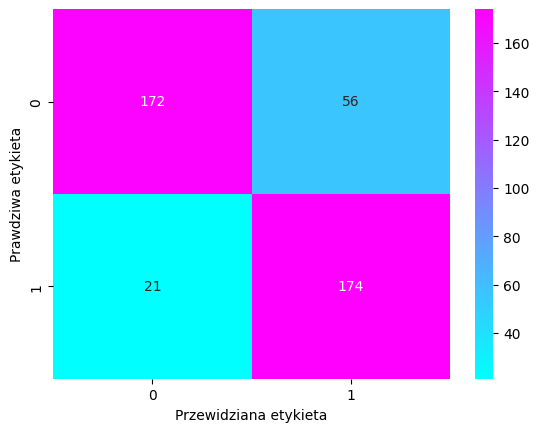

              precision    recall  f1-score   support

           0       0.89      0.75      0.82       228
           1       0.76      0.89      0.82       195

    accuracy                           0.82       423
   macro avg       0.82      0.82      0.82       423
weighted avg       0.83      0.82      0.82       423

f2_score: 0.8613861386138614


In [53]:
best_tree = grid_search_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test)

cm_tree = confusion_matrix(y_true=y_test, y_pred=y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_tree))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_tree, beta=2)}")

## Regresja logistyczna


In [54]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

In [55]:
param_grid_logreg = [
    {
        'logreg__l1_ratio': [0.0],
        'logreg__C': np.logspace(-3, 3, 7),
        'logreg__solver': ['lbfgs', 'saga']
    },
    {
        'logreg__l1_ratio': [1.0],
        'logreg__C': np.logspace(-3, 3, 7),
        'logreg__solver': ['liblinear', 'saga']
    }
]

In [56]:
grid_search_logreg = GridSearchCV(estimator=pipeline, param_grid=param_grid_logreg, cv=5, scoring=f2_score, n_jobs=-2)
grid_search_logreg.fit(X_train, y_train)
print(f"Najlepsze parametry: {grid_search_logreg.best_params_}")

Najlepsze parametry: {'logreg__C': np.float64(0.01), 'logreg__l1_ratio': 1.0, 'logreg__solver': 'saga'}


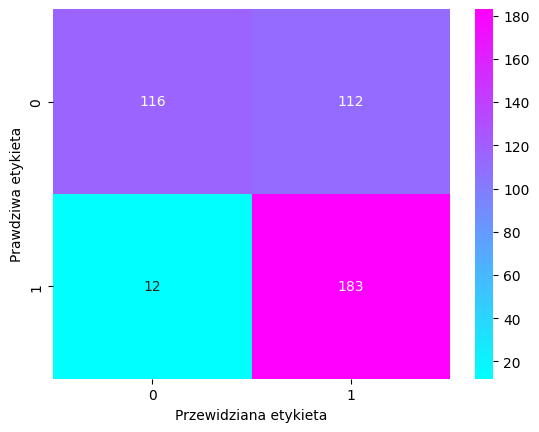

              precision    recall  f1-score   support

           0       0.91      0.51      0.65       228
           1       0.62      0.94      0.75       195

    accuracy                           0.71       423
   macro avg       0.76      0.72      0.70       423
weighted avg       0.77      0.71      0.70       423

f2_score: 0.8511627906976744


In [57]:
best_logreg = grid_search_logreg.best_estimator_
y_pred_logreg = best_logreg.predict(X_test)

cm_logreg = confusion_matrix(y_true=y_test, y_pred=y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_logreg))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_logreg, beta=2)}")

## Param_grid dla baggingu

In [58]:
param_grid_bagging = {
    'n_estimators': [5, 10, 15, 25, 50],
    'bootstrap': [True, False],
    'bootstrap_features': [True, False]
}

## BaggingClassifier z płytkimi drzewami

In [59]:
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
bagging_shallow = BaggingClassifier(estimator=shallow_tree, random_state=42)

grid_search_bagging_shallow = GridSearchCV(estimator=bagging_shallow, param_grid=param_grid_bagging, cv=5, scoring=f2_score, n_jobs=-1)
grid_search_bagging_shallow.fit(X_train, y_train)
print(f"Najlepsze parametry: {grid_search_bagging_shallow.best_params_}")

Najlepsze parametry: {'bootstrap': True, 'bootstrap_features': True, 'n_estimators': 10}


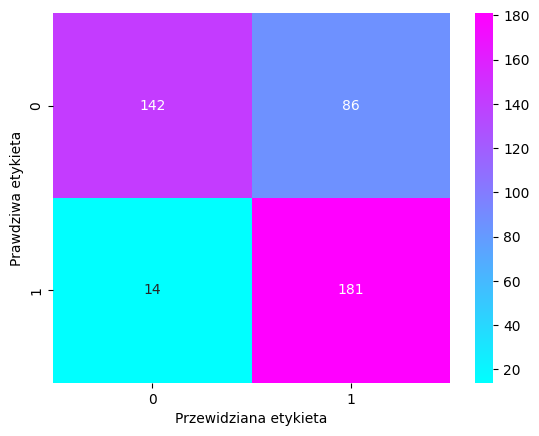

              precision    recall  f1-score   support

           0       0.91      0.62      0.74       228
           1       0.68      0.93      0.78       195

    accuracy                           0.76       423
   macro avg       0.79      0.78      0.76       423
weighted avg       0.80      0.76      0.76       423

f2_score: 0.8643744030563515


In [60]:
best_bagging_shallow = grid_search_bagging_shallow.best_estimator_
y_pred_bagging_shallow = best_bagging_shallow.predict(X_test)

cm_bagging_shallow = confusion_matrix(y_true=y_test, y_pred=y_pred_bagging_shallow)
sns.heatmap(cm_bagging_shallow, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_bagging_shallow))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_bagging_shallow, beta=2)}")

## BaggingClassifier z głębokimi drzewami

In [61]:
deep_tree = DecisionTreeClassifier(max_depth=15, random_state=42)
bagging_deep = BaggingClassifier(estimator=deep_tree, random_state=42)

grid_search_bagging_deep = GridSearchCV(estimator=bagging_deep, param_grid=param_grid_bagging, cv=5, scoring=f2_score, n_jobs=-1)
grid_search_bagging_deep.fit(X_train, y_train)
print(f"Najlepsze parametry: {grid_search_bagging_deep.best_params_}")

Najlepsze parametry: {'bootstrap': True, 'bootstrap_features': False, 'n_estimators': 50}


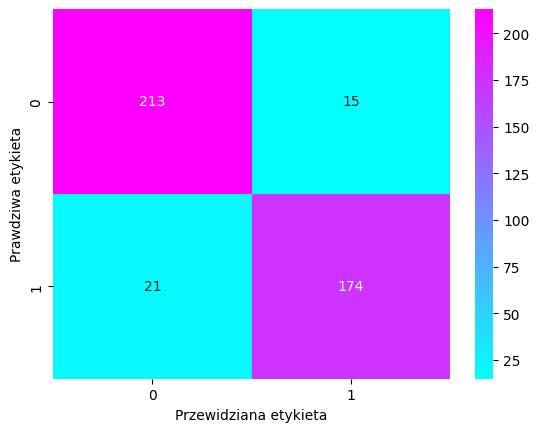

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       228
           1       0.92      0.89      0.91       195

    accuracy                           0.91       423
   macro avg       0.92      0.91      0.91       423
weighted avg       0.92      0.91      0.91       423

f2_score: 0.8978328173374613


In [62]:
best_bagging_deep = grid_search_bagging_deep.best_estimator_
y_pred_bagging_deep = best_bagging_deep.predict(X_test)

cm_bagging_deep = confusion_matrix(y_true=y_test, y_pred=y_pred_bagging_deep)
sns.heatmap(cm_bagging_deep, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_bagging_deep))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_bagging_deep, beta=2)}")

## BaggingClassifier z regresją logistyczną

In [63]:
bagging_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

bagging_logreg = BaggingClassifier(estimator=bagging_pipeline, random_state=42)

grid_search_bagging_logreg = GridSearchCV(estimator=bagging_logreg, param_grid=param_grid_bagging, cv=5, scoring=f2_score, n_jobs=-1)
grid_search_bagging_logreg.fit(X_train, y_train)
print(f"Najlepsze parametry: {grid_search_bagging_logreg.best_params_}")

Najlepsze parametry: {'bootstrap': False, 'bootstrap_features': True, 'n_estimators': 10}


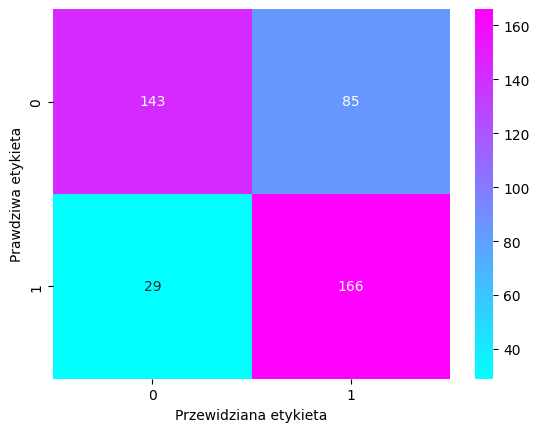

              precision    recall  f1-score   support

           0       0.83      0.63      0.71       228
           1       0.66      0.85      0.74       195

    accuracy                           0.73       423
   macro avg       0.75      0.74      0.73       423
weighted avg       0.75      0.73      0.73       423

f2_score: 0.8050436469447139


In [64]:
best_bagging_logreg = grid_search_bagging_logreg.best_estimator_
y_pred_bagging_logreg = best_bagging_logreg.predict(X_test)

cm_bagging_logreg = confusion_matrix(y_true=y_test, y_pred=y_pred_bagging_logreg)
sns.heatmap(cm_bagging_logreg, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_bagging_logreg))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_bagging_logreg, beta=2)}")

## Param_grid dla boostingu

In [65]:
param_grid_adaboost = {
    'n_estimators': [25, 50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

## AdaBoostClassifier z płytkimi drzewami

In [66]:
shallow_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
adaboost_shallow = AdaBoostClassifier(estimator=shallow_tree, random_state=42)

grid_search_adaboost_shallow = GridSearchCV(estimator=adaboost_shallow, param_grid=param_grid_adaboost, cv=5, scoring=f2_score, n_jobs=-1)
grid_search_adaboost_shallow.fit(X_train, y_train)
print(f"Najlepsze parametry: {grid_search_adaboost_shallow.best_params_}")

Najlepsze parametry: {'learning_rate': 0.1, 'n_estimators': 100}


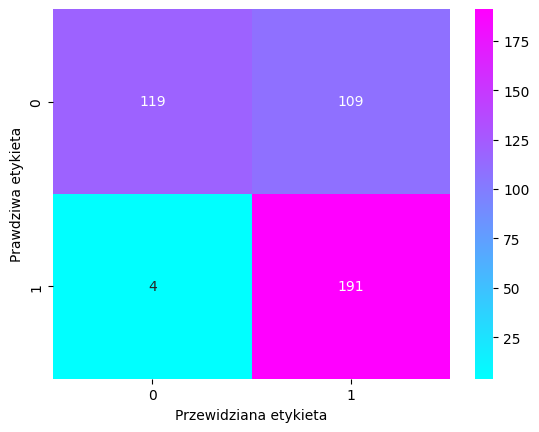

              precision    recall  f1-score   support

           0       0.97      0.52      0.68       228
           1       0.64      0.98      0.77       195

    accuracy                           0.73       423
   macro avg       0.80      0.75      0.72       423
weighted avg       0.81      0.73      0.72       423

f2_score: 0.8842592592592593


In [67]:
best_adaboost_shallow = grid_search_adaboost_shallow.best_estimator_
y_pred_adaboost_shallow = best_adaboost_shallow.predict(X_test)

cm_adaboost_shallow = confusion_matrix(y_true=y_test, y_pred=y_pred_adaboost_shallow)
sns.heatmap(cm_adaboost_shallow, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_adaboost_shallow))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_adaboost_shallow, beta=2)}")

## AdaBoostClassifier z regresją logistyczną

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
adaboost_logreg = AdaBoostClassifier(estimator=logreg, random_state=42)

grid_search_adaboost_logreg = GridSearchCV(estimator=adaboost_logreg, param_grid=param_grid_adaboost, cv=5, scoring=f2_score, n_jobs=-1)
grid_search_adaboost_logreg.fit(X_train_scaled, y_train)
print(f"Najlepsze parametry: {grid_search_adaboost_logreg.best_params_}")

Najlepsze parametry: {'learning_rate': 0.5, 'n_estimators': 25}


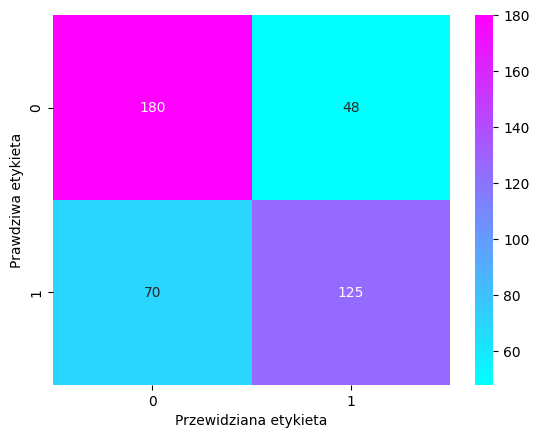

              precision    recall  f1-score   support

           0       0.72      0.79      0.75       228
           1       0.72      0.64      0.68       195

    accuracy                           0.72       423
   macro avg       0.72      0.72      0.72       423
weighted avg       0.72      0.72      0.72       423

f2_score: 0.6558237145855194


In [70]:
best_adaboost_logreg = grid_search_adaboost_logreg.best_estimator_
y_pred_adaboost_logreg = best_adaboost_logreg.predict(X_test_scaled)

cm_adaboost_logreg = confusion_matrix(y_true=y_test, y_pred=y_pred_adaboost_logreg)
sns.heatmap(cm_adaboost_logreg, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_adaboost_logreg))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_adaboost_logreg, beta=2)}")

## GradientBoostingClassifier

In [71]:
gbc = GradientBoostingClassifier(random_state=42)

param_grid_gbc = {
    'n_estimators': [25, 50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'max_depth': [3]
}

grid_search_gbc = GridSearchCV(estimator=gbc, param_grid=param_grid_gbc, cv=5, scoring=f2_score, n_jobs=-1)
grid_search_gbc.fit(X_train, y_train)
print(f"Najlepsze parametry: {grid_search_gbc.best_params_}")

Najlepsze parametry: {'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 200}


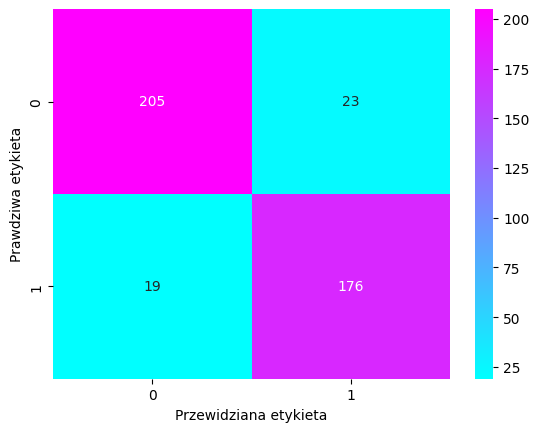

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       228
           1       0.88      0.90      0.89       195

    accuracy                           0.90       423
   macro avg       0.90      0.90      0.90       423
weighted avg       0.90      0.90      0.90       423

f2_score: 0.898876404494382


In [72]:
best_gbc = grid_search_gbc.best_estimator_
y_pred_gbc = best_gbc.predict(X_test)

cm_gbc = confusion_matrix(y_true=y_test, y_pred=y_pred_gbc)
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_gbc))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_gbc, beta=2)}")

## VotingClassifier

In [78]:
voting_estimators = [
    ('dt', best_tree),
    ('lr', best_logreg),
    ('gbc', best_gbc)
]

voting = VotingClassifier(estimators=voting_estimators, voting='soft')
voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_test)

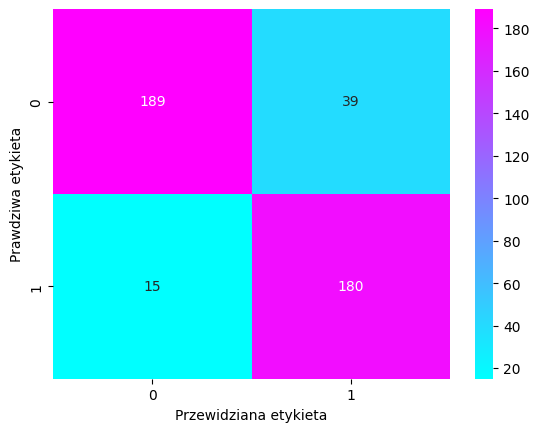

              precision    recall  f1-score   support

           0       0.93      0.83      0.88       228
           1       0.82      0.92      0.87       195

    accuracy                           0.87       423
   macro avg       0.87      0.88      0.87       423
weighted avg       0.88      0.87      0.87       423

f2_score: 0.9009009009009009


In [79]:
cm_voting = confusion_matrix(y_true=y_test, y_pred=y_pred_voting)
sns.heatmap(cm_voting, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_voting))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_voting, beta=2)}")

## StackingClassifier

In [81]:
stacking_estimators = [('dt', best_tree), ('gbc', best_gbc)]

stacking = StackingClassifier(estimators=stacking_estimators, final_estimator=LogisticRegression(max_iter=1000, random_state=42), cv=5)
stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)

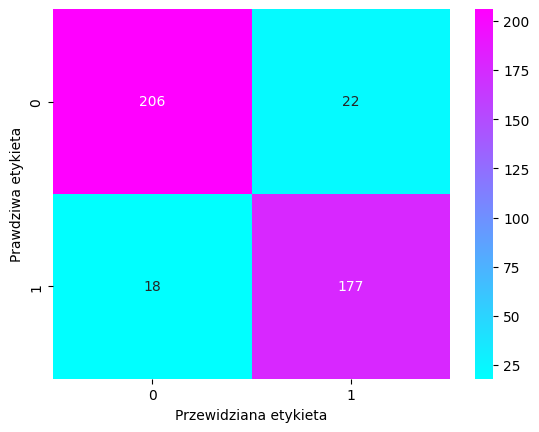

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       228
           1       0.89      0.91      0.90       195

    accuracy                           0.91       423
   macro avg       0.90      0.91      0.90       423
weighted avg       0.91      0.91      0.91       423

f2_score: 0.9039836567926456


In [82]:
cm_stacking = confusion_matrix(y_true=y_test, y_pred=y_pred_stacking)
sns.heatmap(cm_stacking, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_stacking))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_stacking, beta=2)}")

## Ewaluacja wybranych modeli

Wybrałem modele z największym f2_score do dalszych badań pewności jak i czasu predykcji

In [93]:
models_to_evaluate = {
    'Logistic Regression': best_logreg,
    'Decision Tree': best_tree,
    'Bagging (Deep)': best_bagging_deep,
    'AdaBoost (shallow)': best_adaboost_shallow,
    'Gradient Boosting': best_gbc,
    'Voting': voting,
    'Stacking': stacking
}

time_results = {}

for name, model in models_to_evaluate.items():
    start_time = time.perf_counter()
    model.predict(X_test)
    end_time = time.perf_counter()
    time_results[name] = end_time - start_time

predict_results = {}

for name, model in models_to_evaluate.items():
    probabilities = model.predict_proba(X_test)
    prob_positive = probabilities[:, 1]
    brier = brier_score_loss(y_test, prob_positive)
    predict_results[name] = brier

Text(0.5, 1.0, 'Ocena pewności modelu (brier score) (mniej = lepiej)')

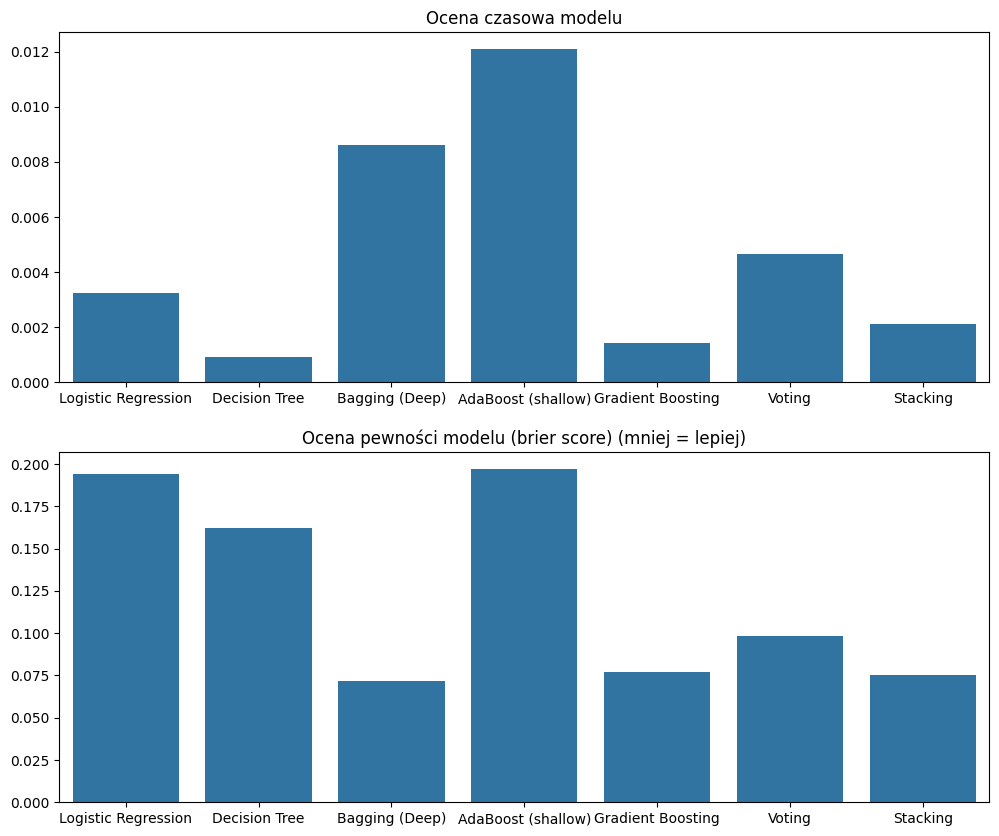

In [101]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
sns.barplot(data=time_results, ax=axes[0])
axes[0].set_title("Ocena czasowa modelu")
sns.barplot(data=predict_results, ax=axes[1])
axes[1].set_title("Ocena pewności modelu (brier score) (mniej = lepiej)")

## Podsumownie

Wybieramy GradientBoosting ponieważ jed on drugim najpewniejszym modelem z wybranych oraz ma względnie szybki czas działania oraz poziom f2_score na poziomie 0.89